# Hierarchical Inference Evaluation
This notebook evaluates the tiered CatBoost models in sequence:
1. **Model 0-4**: If it predicts 0, keep it. Else, pass to Model 1-4.
2. **Model 1-4**: If it predicts 1, keep it. Else, pass to Model 2-4.
3. **Model 2-4**: If it predicts 2, keep it. Else, pass to Model 3-4.
4. **Model 3-4**: Final prediction (3 or 4).

In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ---------------------------------------------------------
# 1. Load the Test Dataset
# ---------------------------------------------------------
print("Loading test dataset...")
DATA_PATH = '../processed_datasets/'
X_TEST_PATH = DATA_PATH + 'X_test_catboost.parquet'
Y_TEST_PATH = DATA_PATH + 'y_test.csv'

X_test = pd.read_parquet(X_TEST_PATH, engine="fastparquet")
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

print(f"Test shape: X={X_test.shape}, y={y_test.shape}")

Loading test dataset...
Test shape: X=(115998, 32), y=(115998,)


In [3]:
# ---------------------------------------------------------
# 2. Load the Tiered Models
# ---------------------------------------------------------
print("Loading models...")

model_0to4 = CatBoostClassifier().load_model("catboost_model_0to4.cbm")
model_1to4 = CatBoostClassifier().load_model("catboost_model_1to4.cbm")
model_2to4 = CatBoostClassifier().load_model("catboost_model_2to4.cbm")
# model_3to4 = CatBoostClassifier().load_model("catboost_model_3to4.cbm")

# Note: Assuming a model_3to4.cbm exists or will be created. 
# If not yet available, we can use model_2to4's prediction for 3 and 4 as a fallback.
import os
if os.path.exists("catboost_model_3to4.cbm"):
    model_3to4 = CatBoostClassifier().load_model("catboost_model_3to4.cbm")
    has_3to4 = True
else:
    print("Warning: catboost_model_3to4.cbm not found. Model 2to4 will handle final decision.")
    has_3to4 = False

Loading models...


In [4]:
# ---------------------------------------------------------
# 3. Hierarchical Inference Logic
# ---------------------------------------------------------
print("Running hierarchical inference...")

final_predictions = np.zeros(len(X_test))

# Step 1: Predict with Model 0-4
preds_0 = model_0to4.predict(X_test).flatten()

for i in range(len(X_test)):
    if preds_0[i] == 0:
        final_predictions[i] = 0
    else:
        # Step 2: Observations > 0 go to Model 1-4
        row = X_test.iloc[[i]]
        pred_1 = model_1to4.predict(row).flatten()[0]
        
        if pred_1 == 1:
            final_predictions[i] = 1
        else:
            # Step 3: Observations > 1 go to Model 2-4
            pred_2 = model_2to4.predict(row).flatten()[0]
            
            if pred_2 == 2 or not has_3to4:
                final_predictions[i] = pred_2
            else:
                # Step 4: Observations > 2 go to Model 3-4
                pred_3 = model_3to4.predict(row).flatten()[0]
                final_predictions[i] = pred_3

print("Inference complete.")

Running hierarchical inference...
Inference complete.



--- Hierarchical Model Performance ---
Accuracy: 0.7942
Macro F1: 0.4819

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.86      0.90     86950
           1       0.62      0.76      0.68     17859
           2       0.28      0.29      0.29      7736
           3       0.19      0.36      0.25      2274
           4       0.24      0.39      0.30      1179

    accuracy                           0.79    115998
   macro avg       0.45      0.53      0.48    115998
weighted avg       0.83      0.79      0.81    115998



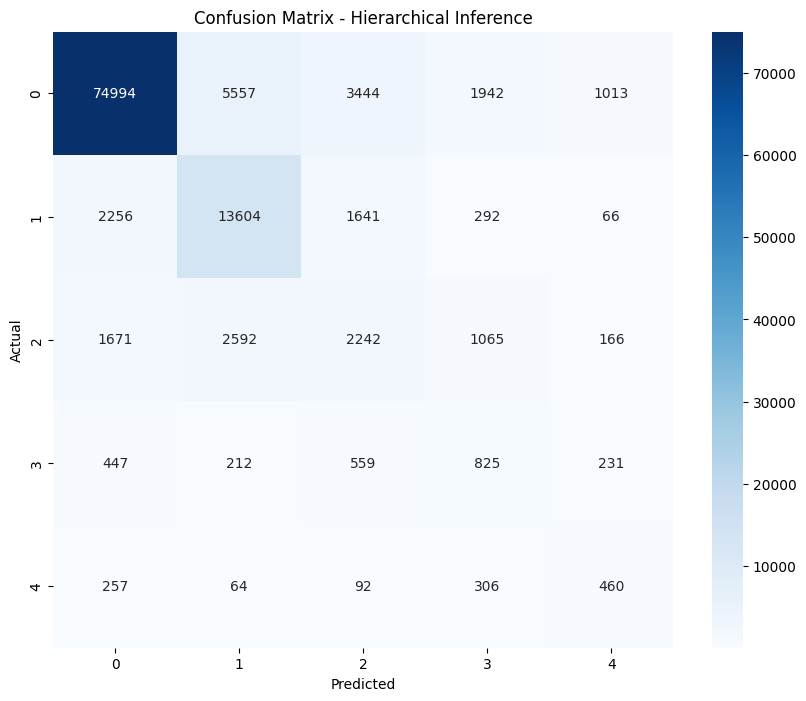

In [5]:
# ---------------------------------------------------------
# 4. Final Evaluation
# ---------------------------------------------------------
print("\n--- Hierarchical Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, final_predictions):.4f}")
print(f"Macro F1: {f1_score(y_test, final_predictions, average='macro'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Hierarchical Inference')
plt.show()